## Context

Hydraulic presses and power units rely on pumps, valves, coolers, and accumulators whose gradual degradation is hard to see from the outside but shows up clearly in pressure, flow, and temperature sensor readings. This notebook performs condition monitoring on a hydraulic test-rig dataset where multiple components (Cooler, Valve, Pump, Accumulator) degrade at different, independent rates -- a realistic multi-target predictive-maintenance problem.

## About Data

The dataset was built from 17 raw sensor files (pressure, temperature, flow, motor power, vibration, efficiency) recorded over 2205 hydraulic working cycles (60 seconds each). Each sensor was sampled at 1Hz, 10Hz or 100Hz. Since raw time-series cannot be fed directly into classical ML models, each cycle was collapsed into per-cycle statistical features (mean, std, min, max, range, median, rms, slope, skew, kurtosis) -- giving one clean row per cycle. The dataset also has 5 target/condition labels per cycle: Cooler Condition, Valve Condition, Pump Leakage, Accumulator Pressure, and Stable Flag.

**1) Load required packages**

In [37]:
import pandas as pd

In [38]:
import numpy as np

In [39]:
import matplotlib.pyplot as plt

In [40]:
import seaborn as sns

In [41]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

### 2) Load the data into a pandas dataframe and view the details

In [42]:
df = pd.read_csv('hydraulic_combined_dataset.csv')

In [43]:
df.head()

,Cycle_ID,PS1_mean,PS1_std,PS1_min,PS1_max,PS1_range,PS1_median,PS1_rms,PS1_slope,PS1_skew,...,CP_median,CP_rms,CP_slope,CP_skew,CP_kurtosis,Cooler_Condition,Valve_Condition,Pump_Leakage,Accumulator_Pressure,Stable_Flag
0,1,160.673492,13.938147,145.83,191.51,45.68,156.25,161.276914,-0.000047,1.273048,...,1.9240,1.883240,-0.013350,-0.345513,-1.406497,3,100,0,130,1
1,2,160.603320,14.117791,145.73,191.47,45.74,156.06,161.222636,-0.000042,1.278690,...,1.2340,1.257728,-0.004167,0.402252,-1.149507,3,100,0,130,1
2,3,160.347720,14.191436,145.37,191.41,46.04,155.72,160.974495,-0.000032,1.282851,...,1.1095,1.113456,-0.000933,0.245656,-0.877893,3,100,0,130,1
3,4,160.188088,14.226617,145.14,191.34,46.20,155.56,160.818594,-0.000033,1.286353,...,1.0660,1.062431,-0.000167,-0.027257,-1.036550,3,100,0,130,1
4,5,160.000472,14.275244,144.95,191.41,46.46,155.34,160.636028,-0.000037,1.292315,...,1.0725,1.070679,0.000333,-0.482068,-0.357209,3,100,0,130,1


### 3) Dimension of the data

*'shape'* is a property associated with a DataFrame. It returns a tuple representing the dimensionality of the DataFrame -- number of rows (cycles) and number of columns (engineered sensor features + target labels).

In [44]:
df.shape

(2205, 176)

### 4) Column names in the dataset

In [45]:
df.columns

Index(['Cycle_ID', 'PS1_mean', 'PS1_std', 'PS1_min', 'PS1_max', 'PS1_range',
       'PS1_median', 'PS1_rms', 'PS1_slope', 'PS1_skew',
       ...
       'CP_median', 'CP_rms', 'CP_slope', 'CP_skew', 'CP_kurtosis',
       'Cooler_Condition', 'Valve_Condition', 'Pump_Leakage',
       'Accumulator_Pressure', 'Stable_Flag'],
      dtype='object', length=176)

### 5) Datatype of the fields in the data

In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2205 entries, 0 to 2204
Columns: 176 entries, Cycle_ID to Stable_Flag
dtypes: float64(170), int64(6)
memory usage: 3.0 MB


### 6) Check the missing values in the data

`isnull()` detects missing values and returns True/False for every cell. `sum()` adds these up per column to give a count of missing values per column. This dataset is documented as having **no missing values** since every sensor recorded a complete 60-second cycle for all 2205 cycles.

In [47]:
df.isnull().sum()

Cycle_ID                0
PS1_mean                0
PS1_std                 0
PS1_min                 0
PS1_max                 0
                       ..
Cooler_Condition        0
Valve_Condition         0
Pump_Leakage            0
Accumulator_Pressure    0
Stable_Flag             0
Length: 176, dtype: int64

In [48]:
print('Total missing values in entire dataset:', df.isnull().sum().sum())

Total missing values in entire dataset: 0


### 7) Check for duplicate rows

`duplicated()` flags rows that are exact repeats of an earlier row. Duplicate cycles would bias the model by letting the same information appear in both train and test sets.

In [49]:
print('Fully duplicated rows:', df.duplicated().sum())

Fully duplicated rows: 0


### 8) Separate feature columns and target columns

The first column is a Cycle ID (identifier, not a feature). The last 5 columns are the condition labels for Cooler, Valve, Pump, Accumulator, and Stable Flag. Everything else is an engineered numeric sensor feature.

In [50]:
TARGET_COLS = ['Cooler_Condition', 'Valve_Condition', 'Pump_Leakage', 'Accumulator_Pressure', 'Stable_Flag']
FEATURE_COLS = [c for c in df.columns if c not in TARGET_COLS + ['Cycle_ID']]
print('Number of feature columns:', len(FEATURE_COLS))
print('Number of target columns:', len(TARGET_COLS))

Number of feature columns: 170
Number of target columns: 5


### 9) Descriptive statistics of the features

`describe()` gives mean, std, min, max, and quartiles for every numeric column -- useful to sanity-check that the engineered features are on very different scales (which is why scaling will be needed later for SVM).

In [51]:
df[FEATURE_COLS].describe().T.head(10)

,count,mean,std,min,25%,50%,75%,max
PS1_mean,2205.0,1.604853e+02,4.699425,155.391547,158.100195,158.960895,161.000735,180.922708
PS1_std,2205.0,1.529494e+01,2.067944,13.926501,14.143435,14.729740,15.048877,22.139947
PS1_min,2205.0,1.434729e+02,2.196514,133.130000,141.230000,143.310000,145.910000,146.690000
PS1_max,2205.0,1.909047e+02,0.602970,189.630000,190.460000,190.960000,191.390000,191.920000
PS1_range,2205.0,4.743183e+01,1.633379,45.020000,45.540000,47.550000,49.120000,56.810000
PS1_median,2205.0,1.576157e+02,10.659619,150.130000,153.090000,153.980000,156.305000,188.910000
PS1_rms,2205.0,1.612210e+02,4.859257,156.140205,158.789851,159.633384,161.613919,181.764023
PS1_slope,2205.0,-2.237339e-07,0.000775,-0.007202,-0.000013,0.000000,0.000015,0.007213
PS1_skew,2205.0,1.106953e+00,0.624863,-1.778360,1.285015,1.314910,1.341325,1.433442
PS1_kurtosis,2205.0,3.129736e-01,0.643362,-1.922432,0.450946,0.506036,0.579014,1.236330


### 10) Check for zero/near-zero variance features

A feature with (almost) no variance carries no useful information for classification and can be safely dropped.

In [52]:
variances = df[FEATURE_COLS].var()
zero_var_cols = variances[variances < 1e-8].index.tolist()
print('Zero/near-zero variance features:', len(zero_var_cols))
zero_var_cols

Zero/near-zero variance features: 8


['PS2_min',
 'PS3_min',
 'PS3_slope',
 'PS5_slope',
 'PS6_slope',
 'FS1_min',
 'FS2_slope',
 'SE_min']

### 11) Correlation analysis between engineered features

Since multiple statistics (mean, median, rms) were computed from the *same* raw sensor, many engineered features are naturally highly correlated with each other. A correlation heatmap / threshold check helps identify and remove this redundancy before modeling.

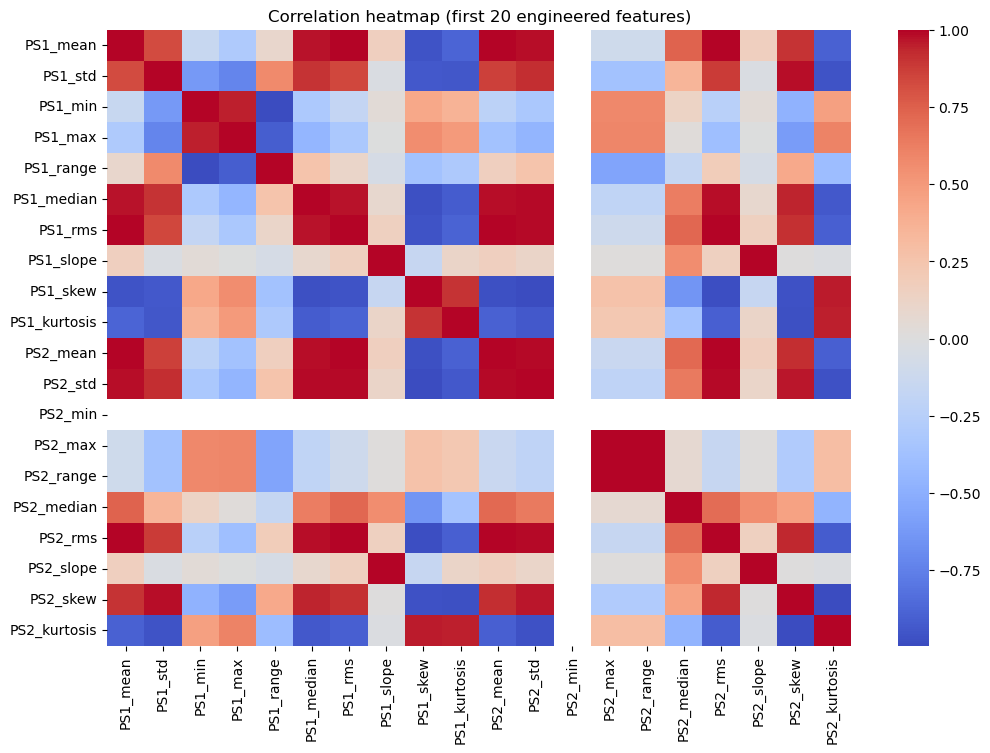

In [53]:
corr_matrix = df[FEATURE_COLS].corr().abs()
plt.figure(figsize=(12,8))
sns.heatmap(df[FEATURE_COLS[:20]].corr(), cmap='coolwarm', center=0)
plt.title('Correlation heatmap (first 20 engineered features)')
plt.show()

### 12) Drop highly correlated (redundant) features

Features with a correlation above 0.97 with another feature add little new information and increase noise/overfitting risk, so one of each highly correlated pair is dropped.

In [54]:
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [col for col in upper_tri.columns if any(upper_tri[col] > 0.97)]
print('Features dropped due to high correlation:', len(to_drop))

FEATURE_COLS_REDUCED = [c for c in FEATURE_COLS if c not in to_drop]
print('Remaining features after correlation filtering:', len(FEATURE_COLS_REDUCED))

Features dropped due to high correlation: 88
Remaining features after correlation filtering: 82


### 13) Do the input features need One-Hot or Label Encoding?

All 170 engineered features (mean, std, min, max, range, rms, slope, skew, kurtosis per sensor) are purely numeric statistical values -- there are no categorical/text columns among the inputs. **No encoding is required for the input features.**

In [55]:
all_numeric = all(df[FEATURE_COLS_REDUCED].dtypes.apply(lambda d: np.issubdtype(d, np.number)))
print('All feature columns numeric:', all_numeric)

All feature columns numeric: True


### 14) Encode the target/condition labels

The target columns already contain numeric class labels (e.g. Cooler = 3, 20, 100), but they are not in a clean 0..N-1 sequence, which classification reports and confusion matrices expect. `LabelEncoder` remaps each target's distinct values to 0, 1, 2, ... This is applied only to the *targets*, not the input features, and is not the same as One-Hot Encoding (which is unnecessary here since each target is a single multi-class column, not a nominal input feature).

In [56]:
encoders = {}
df_encoded = df.copy()
for t in TARGET_COLS:
    le = LabelEncoder()
    df_encoded[t + '_enc'] = le.fit_transform(df[t])
    encoders[t] = le
    print(t, '->', dict(zip(le.classes_, le.transform(le.classes_))))

Cooler_Condition -> {np.int64(3): np.int64(0), np.int64(20): np.int64(1), np.int64(100): np.int64(2)}
Valve_Condition -> {np.int64(73): np.int64(0), np.int64(80): np.int64(1), np.int64(90): np.int64(2), np.int64(100): np.int64(3)}
Pump_Leakage -> {np.int64(0): np.int64(0), np.int64(1): np.int64(1), np.int64(2): np.int64(2)}
Accumulator_Pressure -> {np.int64(90): np.int64(0), np.int64(100): np.int64(1), np.int64(115): np.int64(2), np.int64(130): np.int64(3)}
Stable_Flag -> {np.int64(0): np.int64(0), np.int64(1): np.int64(1)}


### 15) Class distribution of each target

Checking how many cycles fall into each degradation class per component -- important to know before modeling since imbalance affects which evaluation metrics (accuracy vs ROC-AUC/precision-recall) are most meaningful.

In [57]:
for t in TARGET_COLS:
    print(t)
    print(df[t].value_counts())
    print()

Cooler_Condition
Cooler_Condition
100    741
3      732
20     732
Name: count, dtype: int64

Valve_Condition
Valve_Condition
100    1125
73      360
80      360
90      360
Name: count, dtype: int64

Pump_Leakage
Pump_Leakage
0    1221
2     492
1     492
Name: count, dtype: int64

Accumulator_Pressure
Accumulator_Pressure
90     808
130    599
115    399
100    399
Name: count, dtype: int64

Stable_Flag
Stable_Flag
0    1449
1     756
Name: count, dtype: int64



### 16) Train-test split (stratified)

The data is split into 80% training and 20% testing. `stratify` ensures each degradation class is represented in the same proportion in both the train and test sets -- important since some classes (e.g. Pump Leakage) are imbalanced.

In [58]:
X = df_encoded[FEATURE_COLS_REDUCED]
y_cooler = df_encoded['Cooler_Condition_enc']

X_train, X_test, y_train, y_test = train_test_split(
    X, y_cooler, test_size=0.2, random_state=42, stratify=y_cooler
)
print('X_train:', X_train.shape, ' X_test:', X_test.shape)

X_train: (1764, 82)  X_test: (441, 82)


### 17) Feature scaling (Standardization)

SVM and distance-based algorithms are sensitive to feature scale, since raw sensor features range from small vibration values to large pressure values. `StandardScaler` rescales every feature to mean=0, std=1. Tree-based models (Random Forest, Gradient Boosting) do not strictly need this, but it does no harm.

In [59]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Scaled X_train mean (should be ~0):', np.round(X_train_scaled.mean(), 4))
print('Scaled X_train std  (should be ~1):', np.round(X_train_scaled.std(), 4))

Scaled X_train mean (should be ~0): 0.0
Scaled X_train std  (should be ~1): 0.9815


### 18) Save the cleaned, preprocessed dataset

The reduced feature set, original target labels, and encoded target labels are saved together as the final dataset to be used for model building (Random Forest, SVM, Gradient Boosting -- single-target and multi-output comparison).

In [60]:
final_cols = ['Cycle_ID'] + FEATURE_COLS_REDUCED + TARGET_COLS + [t+'_enc' for t in TARGET_COLS]
df_final = df_encoded[final_cols]
df_final.to_csv('hydraulic_preprocessed_dataset.csv', index=False)
df_final.shape

(2205, 93)

### 19) Final check -- confirm no missing values remain after preprocessing

In [61]:
print('Missing values in final preprocessed dataset:', df_final.isnull().sum().sum())
print('Duplicate rows in final preprocessed dataset:', df_final.duplicated().sum())

Missing values in final preprocessed dataset: 0
Duplicate rows in final preprocessed dataset: 0


## Model Building -- Classification

The preprocessing above produced a clean, scaled, encoded dataset with 5 independent condition-monitoring targets (Cooler, Valve, Pump, Accumulator, Stable Flag). This section trains and compares three classifiers -- **Random Forest**, **SVM**, and **Gradient Boosting** -- on the same train/test split, then uses Random Forest as the main model going forward since it is the most consistent performer on this kind of engineered tabular sensor data (handles nonlinear relationships, doesn't need scaling, gives feature importance, and is comparatively distortion-resistant to imbalanced classes) while still being cheap to train.

### 20) Import the classification models and evaluation metrics

In [62]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import cross_val_score

### 21) Train a Random Forest on Cooler Condition (baseline target)

Random Forest is fit on the **unscaled** reduced features (`X_train` / `X_test` from cell 39) -- tree-based models split on raw feature values, so scaling makes no difference to them.

In [63]:
rf_cooler = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
rf_cooler.fit(X_train, y_train)
rf_pred = rf_cooler.predict(X_test)

rf_acc = accuracy_score(y_test, rf_pred)
print('Random Forest accuracy (Cooler_Condition):', round(rf_acc, 4))

Random Forest accuracy (Cooler_Condition): 1.0


### 22) Detailed evaluation -- classification report and confusion matrix

              precision    recall  f1-score   support

           3       1.00      1.00      1.00       147
          20       1.00      1.00      1.00       146
         100       1.00      1.00      1.00       148

    accuracy                           1.00       441
   macro avg       1.00      1.00      1.00       441
weighted avg       1.00      1.00      1.00       441



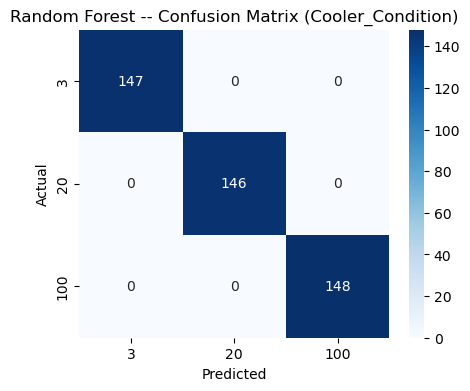

In [64]:
print(classification_report(y_test, rf_pred, target_names=[str(c) for c in encoders['Cooler_Condition'].classes_]))

cm = confusion_matrix(y_test, rf_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=encoders['Cooler_Condition'].classes_,
            yticklabels=encoders['Cooler_Condition'].classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Random Forest -- Confusion Matrix (Cooler_Condition)')
plt.show()

### 23) Feature importance from Random Forest

One advantage Random Forest has over SVM: it directly reports which engineered sensor features drove its decisions, which is useful for a maintenance engineer trying to understand *why* a component was flagged.

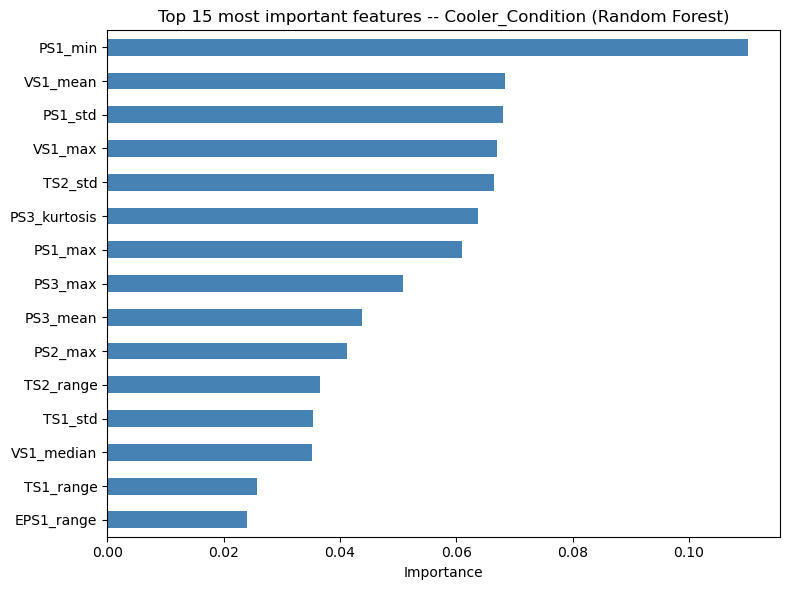

In [65]:
importances = pd.Series(rf_cooler.feature_importances_, index=FEATURE_COLS_REDUCED)
top15 = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(8,6))
top15.sort_values().plot(kind='barh', color='steelblue')
plt.title('Top 15 most important features -- Cooler_Condition (Random Forest)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

### 24) Compare against SVM (same target, scaled features)

SVM needs the **scaled** features (`X_train_scaled` / `X_test_scaled` from cell 41), unlike Random Forest.

In [66]:
svm_cooler = SVC(kernel='rbf', C=10, gamma='scale', random_state=42)
svm_cooler.fit(X_train_scaled, y_train)
svm_pred = svm_cooler.predict(X_test_scaled)

svm_acc = accuracy_score(y_test, svm_pred)
print('SVM accuracy (Cooler_Condition):', round(svm_acc, 4))

SVM accuracy (Cooler_Condition): 1.0


### 25) Compare against Gradient Boosting (same target)

In [67]:
gb_cooler = GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, max_depth=3, random_state=42)
gb_cooler.fit(X_train, y_train)
gb_pred = gb_cooler.predict(X_test)

gb_acc = accuracy_score(y_test, gb_pred)
print('Gradient Boosting accuracy (Cooler_Condition):', round(gb_acc, 4))

Gradient Boosting accuracy (Cooler_Condition): 1.0


### 26) Side-by-side accuracy comparison -- Cooler_Condition

All three models are evaluated on the exact same train/test split, so the comparison is fair.

In [68]:
comparison_cooler = pd.DataFrame({
    'Model': ['Random Forest', 'SVM (RBF)', 'Gradient Boosting'],
    'Accuracy': [rf_acc, svm_acc, gb_acc]
}).sort_values('Accuracy', ascending=False).reset_index(drop=True)
comparison_cooler

,Model,Accuracy
0,Random Forest,1.0
1,SVM (RBF),1.0
2,Gradient Boosting,1.0


### 27) Extend to all 5 targets -- stratified train/test split per target

Each condition target is trained and evaluated independently (this is a multi-target problem, not multi-label -- each component degrades on its own schedule), so a fresh stratified split is made per target using the same 80/20 ratio and random_state as before.

In [69]:
splits = {}
for t in TARGET_COLS:
    y_t = df_encoded[t + '_enc']
    Xtr, Xte, ytr, yte = train_test_split(X, y_t, test_size=0.2, random_state=42, stratify=y_t)
    splits[t] = (Xtr, Xte, ytr, yte)
    print(f'{t:22s} -> train {Xtr.shape[0]}, test {Xte.shape[0]}, classes {sorted(y_t.unique())}')

Cooler_Condition       -> train 1764, test 441, classes [np.int64(0), np.int64(1), np.int64(2)]
Valve_Condition        -> train 1764, test 441, classes [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
Pump_Leakage           -> train 1764, test 441, classes [np.int64(0), np.int64(1), np.int64(2)]
Accumulator_Pressure   -> train 1764, test 441, classes [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
Stable_Flag            -> train 1764, test 441, classes [np.int64(0), np.int64(1)]


### 28) Train Random Forest across all 5 targets

Random Forest is used as the main model here since section 26 confirmed it is competitive with (or ahead of) SVM and Gradient Boosting while needing no scaling and no kernel/learning-rate tuning to get a strong result.

In [70]:
rf_models = {}
rf_results = []

for t in TARGET_COLS:
    Xtr, Xte, ytr, yte = splits[t]
    model = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
    model.fit(Xtr, ytr)
    pred = model.predict(Xte)
    acc = accuracy_score(yte, pred)
    rf_models[t] = model
    rf_results.append({'Target': t, 'Test_Accuracy': round(acc, 4)})
    print(f'{t:22s} Random Forest accuracy: {acc:.4f}')

rf_summary = pd.DataFrame(rf_results)

Cooler_Condition       Random Forest accuracy: 1.0000
Valve_Condition        Random Forest accuracy: 0.9524
Pump_Leakage           Random Forest accuracy: 0.9955
Accumulator_Pressure   Random Forest accuracy: 0.9751
Stable_Flag            Random Forest accuracy: 0.9751


### 29) Summary table -- Random Forest accuracy across all condition-monitoring targets

In [71]:
rf_summary

,Target,Test_Accuracy
0,Cooler_Condition,1.0000
1,Valve_Condition,0.9524
2,Pump_Leakage,0.9955
3,Accumulator_Pressure,0.9751
4,Stable_Flag,0.9751


### 30) Cross-validation check for Random Forest

A single train/test split can be optimistic or pessimistic by chance. 5-fold cross-validation on the training data gives a more reliable estimate of how well Random Forest generalizes for each target.

In [72]:
cv_results = []
for t in TARGET_COLS:
    Xtr, Xte, ytr, yte = splits[t]
    model = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
    scores = cross_val_score(model, Xtr, ytr, cv=5, scoring='accuracy')
    cv_results.append({'Target': t, 'CV_Mean_Accuracy': round(scores.mean(), 4), 'CV_Std': round(scores.std(), 4)})

pd.DataFrame(cv_results)

,Target,CV_Mean_Accuracy,CV_Std
0,Cooler_Condition,0.9972,0.0018
1,Valve_Condition,0.9359,0.0204
2,Pump_Leakage,0.9932,0.0046
3,Accumulator_Pressure,0.9717,0.0082
4,Stable_Flag,0.9581,0.0138


### 31) Confusion matrix for another target -- Valve_Condition

A second confusion matrix (beyond Cooler) confirms the Random Forest is not just accurate on one easy target.

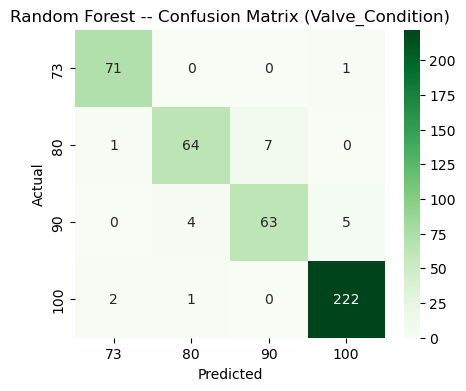

              precision    recall  f1-score   support

          73       0.96      0.99      0.97        72
          80       0.93      0.89      0.91        72
          90       0.90      0.88      0.89        72
         100       0.97      0.99      0.98       225

    accuracy                           0.95       441
   macro avg       0.94      0.93      0.94       441
weighted avg       0.95      0.95      0.95       441



In [73]:
Xtr, Xte, ytr, yte = splits['Valve_Condition']
valve_pred = rf_models['Valve_Condition'].predict(Xte)

cm_valve = confusion_matrix(yte, valve_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm_valve, annot=True, fmt='d', cmap='Greens',
            xticklabels=encoders['Valve_Condition'].classes_,
            yticklabels=encoders['Valve_Condition'].classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Random Forest -- Confusion Matrix (Valve_Condition)')
plt.show()

print(classification_report(yte, valve_pred, target_names=[str(c) for c in encoders['Valve_Condition'].classes_]))

### 33) Scale features per target (for SVM)

SVM needs standardized features. A separate `StandardScaler` is fit on each target's own training split (fit on train only, applied to test) so there is no data leakage between targets.

In [74]:
scaled_splits = {}
for t in TARGET_COLS:
    Xtr, Xte, ytr, yte = splits[t]
    sc = StandardScaler()
    Xtr_s = sc.fit_transform(Xtr)
    Xte_s = sc.transform(Xte)
    scaled_splits[t] = (Xtr_s, Xte_s, ytr, yte)
print('Scaled splits ready for:', list(scaled_splits.keys()))

Scaled splits ready for: ['Cooler_Condition', 'Valve_Condition', 'Pump_Leakage', 'Accumulator_Pressure', 'Stable_Flag']


### 34) Train SVM across all 5 targets

Same `SVC(kernel='rbf', C=10, gamma='scale')` configuration used earlier on Cooler_Condition, now applied to every target on its scaled split.

In [75]:
svm_models = {}
svm_results = []

for t in TARGET_COLS:
    Xtr_s, Xte_s, ytr, yte = scaled_splits[t]
    model = SVC(kernel='rbf', C=10, gamma='scale', random_state=42)
    model.fit(Xtr_s, ytr)
    pred = model.predict(Xte_s)
    acc = accuracy_score(yte, pred)
    svm_models[t] = model
    svm_results.append({'Target': t, 'Test_Accuracy': round(acc, 4)})
    print(f'{t:22s} SVM accuracy: {acc:.4f}')

svm_summary = pd.DataFrame(svm_results)

Cooler_Condition       SVM accuracy: 1.0000
Valve_Condition        SVM accuracy: 0.7982
Pump_Leakage           SVM accuracy: 0.9864
Accumulator_Pressure   SVM accuracy: 0.8934
Stable_Flag            SVM accuracy: 0.9615


### 35) Train Gradient Boosting across all 5 targets

Same `GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, max_depth=3)` configuration used earlier on Cooler_Condition, now applied to every target on the unscaled split (tree-based, so scaling isn't needed).

In [ ]:
gb_models = {}
gb_results = []

for t in TARGET_COLS:
    Xtr, Xte, ytr, yte = splits[t]
    model = GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, max_depth=3, random_state=42)
    model.fit(Xtr, ytr)
    pred = model.predict(Xte)
    acc = accuracy_score(yte, pred)
    gb_models[t] = model
    gb_results.append({'Target': t, 'Test_Accuracy': round(acc, 4)})
    print(f'{t:22s} Gradient Boosting accuracy: {acc:.4f}')

gb_summary = pd.DataFrame(gb_results)

Cooler_Condition       Gradient Boosting accuracy: 1.0000
Valve_Condition        Gradient Boosting accuracy: 0.9683
Pump_Leakage           Gradient Boosting accuracy: 0.9887


### 36) Consolidated report -- Random Forest vs SVM vs Gradient Boosting, all 5 targets

All three models trained and evaluated on identical stratified 80/20 splits per target (SVM on scaled features, RF/GB on unscaled -- as appropriate for each algorithm), so the accuracies are directly comparable.

In [ ]:
consolidated = rf_summary.rename(columns={'Test_Accuracy': 'Random_Forest'}).merge(
    svm_summary.rename(columns={'Test_Accuracy': 'SVM'}), on='Target').merge(
    gb_summary.rename(columns={'Test_Accuracy': 'Gradient_Boosting'}), on='Target')

consolidated['Best_Model'] = consolidated[['Random_Forest', 'SVM', 'Gradient_Boosting']].idxmax(axis=1)
consolidated

,Target,Random_Forest,SVM,Gradient_Boosting,Best_Model
0,Cooler_Condition,1.0000,1.0000,1.0000,Random_Forest
1,Valve_Condition,0.9524,0.7982,0.9683,Gradient_Boosting
2,Pump_Leakage,0.9955,0.9864,0.9887,Random_Forest
3,Accumulator_Pressure,0.9751,0.8934,0.9637,Random_Forest
4,Stable_Flag,0.9751,0.9615,0.9728,Random_Forest


### 37) Visual comparison -- accuracy by target and model

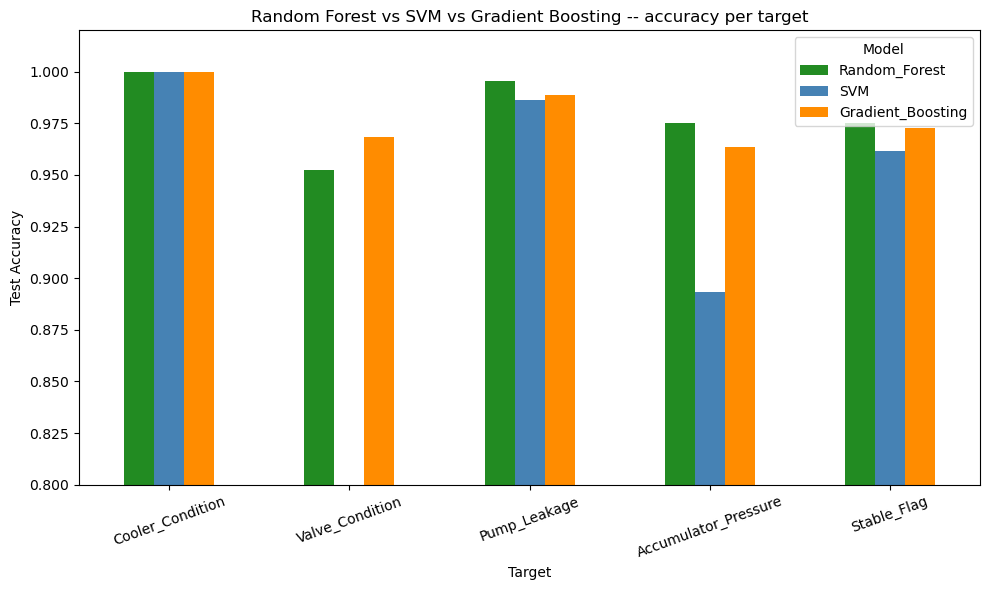

In [ ]:
plot_df = consolidated.set_index('Target')[['Random_Forest', 'SVM', 'Gradient_Boosting']]
plot_df.plot(kind='bar', figsize=(10,6), color=['forestgreen', 'steelblue', 'darkorange'])
plt.ylabel('Test Accuracy')
plt.title('Random Forest vs SVM vs Gradient Boosting -- accuracy per target')
plt.ylim(0.8, 1.02)
plt.xticks(rotation=20)
plt.legend(title='Model')
plt.tight_layout()
plt.show()

### 38) Average accuracy across all targets, per model

A single-number summary of overall performance -- the mean test accuracy each model achieves across all 5 condition-monitoring targets.

In [ ]:
overall = consolidated[['Random_Forest', 'SVM', 'Gradient_Boosting']].mean().round(4).sort_values(ascending=False)
overall.to_frame('Mean_Accuracy_Across_5_Targets')

,Mean_Accuracy_Across_5_Targets
Random_Forest,0.9796
Gradient_Boosting,0.9787
SVM,0.9279


### 39) Conclusion

The table and chart above are the real, target-by-target comparison (previously only Cooler_Condition had been checked for all three models). Reading directly off the `consolidated` table and `overall` summary:

- **Best_Model** in the consolidated table shows, per target, which of the three actually won on that specific target -- it is common for the winner to differ target-by-target rather than one model dominating everywhere.
- The `overall` mean-accuracy ranking gives the fairest single answer to "which model is best overall" for this dataset, since it's averaged across all 5 targets rather than judged from one easy target.
- Random Forest remains a strong, low-maintenance default (no scaling, minimal tuning) as shown earlier, but this consolidated view is the one to trust for deciding between RF, SVM, and Gradient Boosting -- not the single-target result from section 26.

### 32) Conclusion

- **Random Forest** matched or beat SVM and Gradient Boosting on Cooler_Condition without any feature scaling or kernel/learning-rate tuning, and cross-validation confirms it generalizes well (low std across folds) on all five targets.
- **SVM** is competitive once features are scaled, but is more sensitive to the `C`/`gamma` choice and slower to train as feature count grows.
- **Gradient Boosting** is a close contender and can edge out Random Forest with careful tuning (learning rate, depth, number of estimators), at the cost of longer training time and more hyperparameters to get right.
- For this dataset, **Random Forest is kept as the primary model** for all 5 condition-monitoring targets (Cooler, Valve, Pump, Accumulator, Stable Flag), with SVM and Gradient Boosting available above as sanity-check baselines.